In [1]:
import os
import sys
import math
import random
import torch

sys.path.append("..")
from io import BytesIO
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import requests
import zarr
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb
from models.MAE import MaskedAutoencoderViT

from utils.DataProcessing import (
    generate_rest_indices,
    get_extreme_mask,
    get_kernel,
    safe_collate,
    smooth_data,
    MultimodalDataset,
    CreateMultimodalDataLoadersIter,
)

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from models.MAE import MaskedAutoencoderViT
# path = "/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsFinal/epoch=005-val_loss=-1.0120.ckpt"
path = "/pscratch/sd/p/pzehao/DESIMAE/Final/epoch=097-val_loss=-2.2914.ckpt"
# path = "/pscratch/sd/p/pzehao/DESIMAE/ImageMHP/epoch=225-val_loss=-2.3145.ckpt"


prob = 0.7/15

model = MaskedAutoencoderViT(spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim        = 256,
        merged_depth     = 4,
        merged_num_heads = 8,
        s_depth          = 4,
        e_depth          = 4,
        s_num_heads      = 8,
        e_num_heads      = 8,
        decoder_embed_dim= 512,
        decoder_depth    = 8,
        decoder_num_heads= 16,
        decoder_MLP_coefficient = 1,
        patch_scheme={
            "patch_sizes": [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            "mask_ratios": [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            "probs": [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob]
        })
# load model from checkpoint (non-strict for backward compatibility)
checkpoint = torch.load(path, map_location="cpu")
model.load_state_dict(checkpoint["state_dict"], strict=False)
model.eval()

/tmp/ipykernel_2318985/955404685.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")


MaskedAutoencoderViT(
  (patch_embed1d): PatchEmbed1D(
    (proj): Conv1d(1, 256, kernel_size=(31,), stride=(31,))
    (norm): Identity()
  )
  (patch_embedimg): PatchEmbed(
    (proj): Conv2d(1, 256, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (s_attn): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (d

In [4]:
ds = MultimodalDataset('/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr', start=0, end=4737442)
sample = ds[1108394]  # TARGETID=39627790139533968, DESI_INDEX=1108394
spec, spec2, ivar, error, img, img_ivar, img_error, z, xy_pix = sample
print(f"z={z.item():.4f}, spec shape={spec.shape}, img shape={img.shape}")

z=0.0301, spec shape=torch.Size([7781]), img shape=torch.Size([6, 128, 128])


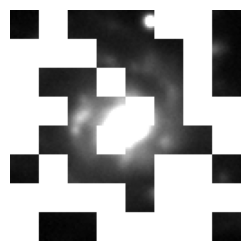

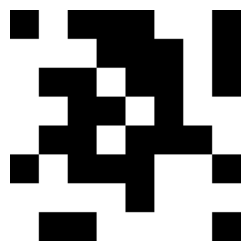

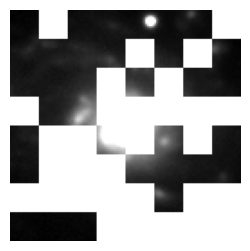

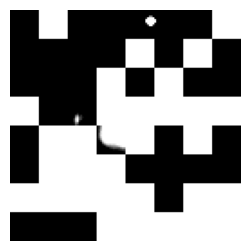

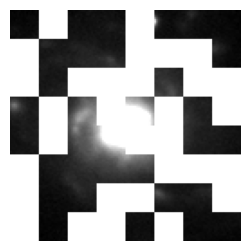

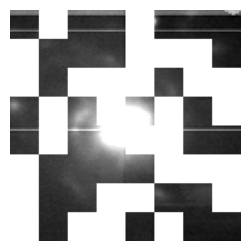

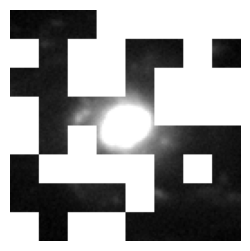

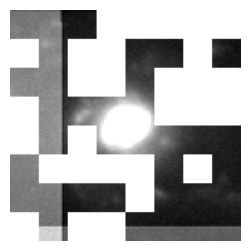

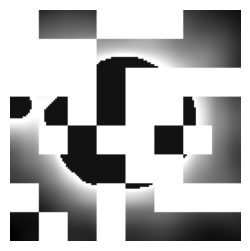

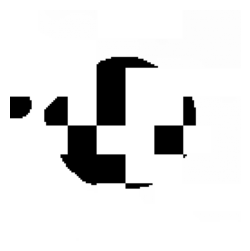

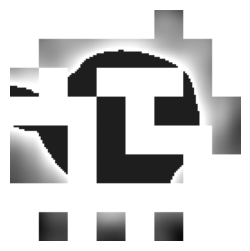

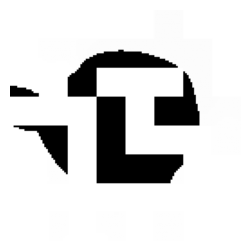

In [20]:
from models.MyTimm import generate_attn_mask

num_channels, img_size, patch_size = 6, 128, 16
grid = img_size // patch_size  # 8
num_patches = num_channels * grid * grid  # 384

# Generate 50% random mask using the model's masking function
token_mask = generate_attn_mask(1, 0.5, num_patches, return_attn_mask=False)
pixel_mask = token_mask.view(num_channels, grid, grid).numpy()
pixel_mask = pixel_mask.repeat(patch_size, axis=1).repeat(patch_size, axis=2)

img_np = img.numpy()
img_err_np = img_error.numpy()

for c in range(num_channels):
    for label, data in [('img', img_np), ('img_err', img_err_np)]:
        chan = data[c]
        vmin, vmax = np.percentile(chan, [0, 97])
        masked = chan.copy()
        masked[pixel_mask[c]] = np.nan
        cmap = plt.cm.gray.copy()
        cmap.set_bad('white')
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(masked, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
        ax.axis('off')
        fig.savefig(f'masked_{label}_ch{c}.png', dpi=200, bbox_inches='tight', pad_inches=0)
        plt.show()

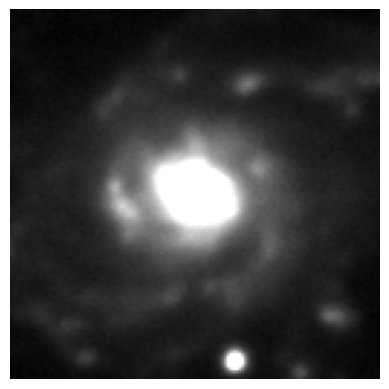

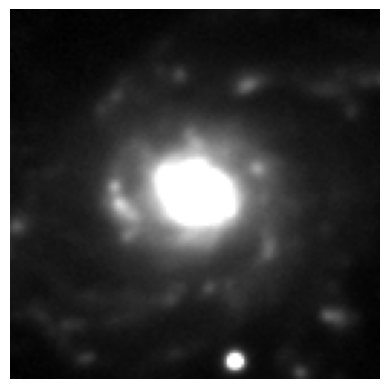

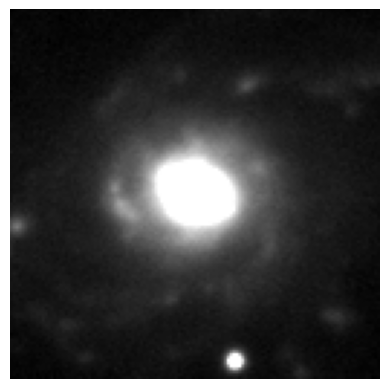

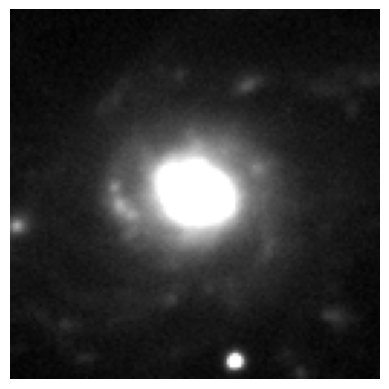

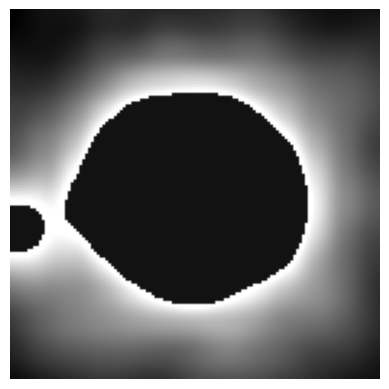

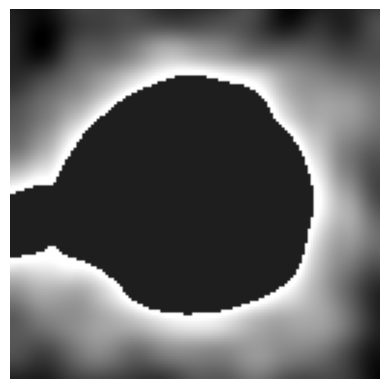

In [17]:
for i in range(6):
    # Set vmin and vmax to be 20th and 80th percentiles of the image for better contrast
    vmin, vmax = np.percentile(img[i], [0, 97])
    plt.imshow(img[i], cmap='gray', vmin=vmin, vmax=vmax)
    plt.axis('off')
    plt.show()